In [ ]:
from google.colab import files
uploaded = files.upload()

Saving customers.csv to customers.csv
Saving deliveries.csv to deliveries.csv
Saving orders.csv to orders.csv


In [ ]:
import pandas as pd

orders = pd.read_csv("orders.csv")
deliveries = pd.read_csv("deliveries.csv")
customers = pd.read_csv("customers.csv")

next data cleaning

In [ ]:
import pandas as pd

orders = pd.read_csv("orders.csv")
orders.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


check missing values

In [ ]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
service_type,0
order_created_at,0
promised_window_hours,0
pickup_zone,0
dropoff_zone,0
priority_level,0
order_value,0
booking_channel,25


data cleaning

In [ ]:
orders = orders.dropna()

check after cleaning missing values

In [ ]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
service_type,0
order_created_at,0
promised_window_hours,0
pickup_zone,0
dropoff_zone,0
priority_level,0
order_value,0
booking_channel,0


data intergration

In [ ]:
merged = pd.merge(orders, deliveries, on="order_id")
full_data = pd.merge(merged, customers, on="customer_id")

In [ ]:
display(merged.head())

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,V090,H01,2024-08-20 16:29:00,2024-08-20 18:52:56.172161,OnTime,26.65,2,0,4.29,15.82
1,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,...,V100,H02,2025-09-02 16:59:00,2025-09-03 01:50:39.644673,Delayed,13.04,2,0,3.70,13.16
2,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,...,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
3,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,...,V073,H03,2025-02-17 20:23:00,2025-02-18 08:05:00.047082,OnTime,16.01,1,0,4.38,13.53
4,O00007,C0001,Business,2024-05-05 21:32:00,2,CENTRAL,Airport,Low,76.12,App,...,V047,H06,2024-05-05 22:10:00,2024-05-06 07:05:17.555250,Delayed,9.07,1,1,3.93,9.76


analysis part

In [ ]:
full_data['order_created_at'] = pd.to_datetime(full_data['order_created_at'])
full_data['delivery_completed_at'] = pd.to_datetime(full_data['delivery_completed_at'])
full_data['delivery_duration'] = (full_data['delivery_completed_at'] - full_data['order_created_at']).dt.total_seconds() / 3600 # in hours
full_data['delay_time'] = full_data['delivery_duration'] - full_data['promised_window_hours']
full_data.groupby("home_zone")["delay_time"].mean()

,delay_time
home_zone,
AIRPORT,4.119423
Airport,4.673859
CENTRAL,4.447147
Central,3.015708
Ctr,2.006906
EAST,3.423675
East,2.934783
NORTH,5.233228
North,3.022825


In [ ]:
failed = full_data[full_data["delivery_status"] == "failed"]

In [ ]:
full_data['delivery_status'].value_counts()

,count
delivery_status,
OnTime,602
Delayed,198
Failed,129


Visulaization

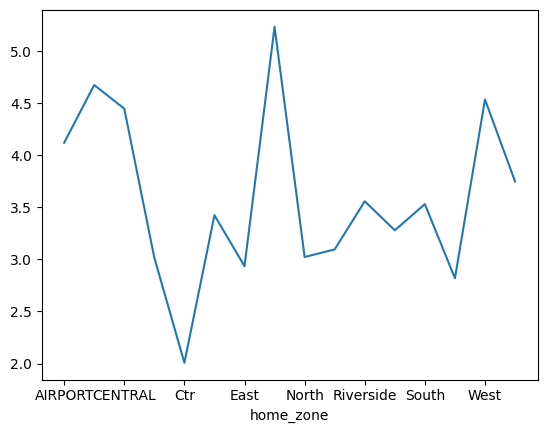

In [ ]:
import matplotlib.pyplot as plt

full_data.groupby("home_zone")["delay_time"].mean().plot()
plt.show()

In [1]:
!git clone https://github.com/Rashmika2004oshan/Database_Assesment.git

Cloning into 'Database_Assesment'...
